# Basic I4C NetCDF data exploration

This notebook performs a basic exploration of NetCDF file contents, plots a map and a time series at a location and saves the output as a CSV.

In [1]:
import glob
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
files = glob.glob('../I4C_CPRCM_CITY_DATA/ALPX-3i-Prague/tasmin_*.nc')
ds = xr.open_mfdataset(files, combine='by_coords')
ds

<xarray.Dataset> Size: 314MB
Dimensions:    (time: 14600, bnds: 2, lat: 59, lon: 91)
Coordinates:
  * time       (time) object 117kB 1995-01-01 11:30:00 ... 2100-12-31 11:30:00
  * lat        (lat) float64 472B 49.17 49.2 49.23 49.27 ... 50.92 50.95 50.98
  * lon        (lon) float64 728B 13.11 13.14 13.17 13.2 ... 15.86 15.89 15.92
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 234kB dask.array<chunksize=(7300, 2), meta=np.ndarray>
    tasmin     (time, lat, lon) float32 314MB dask.array<chunksize=(195, 59, 91), meta=np.ndarray>
Attributes: (12/29)
    CDI:                     Climate Data Interface version 2.5.0 (https://mp...
    Conventions:             CF-1.11
    source:                  Weather Research and Forecasting model version 4...
    institution:             BCCR [Bjerknes Center for Climate Research (BCCR...
    activity_id:             DD
    contact:                 meteo@unican.es
    ...                      ...
    tracking_id:             hdl:21.14103/0a415d37-703a-467a-ab31-6750508fd21d
    variable_id:             tasmin
    comment:                 NorESM2-MM r1i1p1f1 driven simulation for the I4...
    source_id:               WRF451R-CI4C
    history:                 Wed Jun 17 18:46:14 2026: cdo mergetime I4C_CPRC...
    CDO:                     Climate Data Operators version 2.5.0 (https://mp...

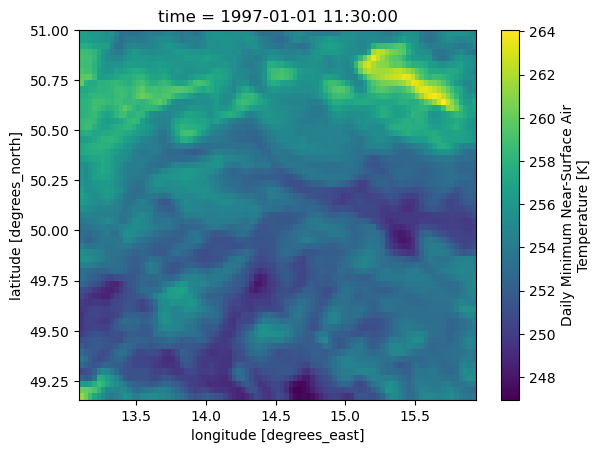

In [3]:
hm = ds.tasmin.sel(time='1997-01-01').plot()

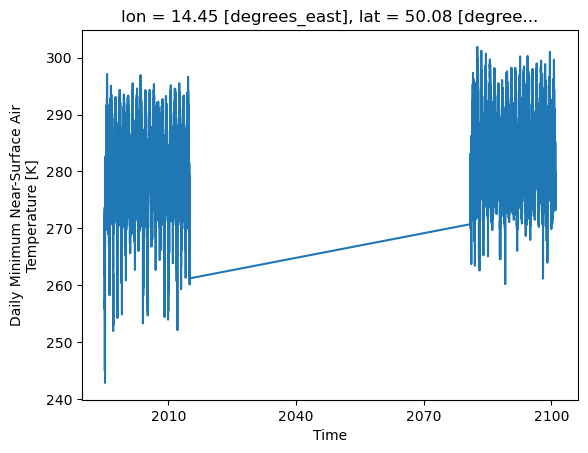

In [4]:
# E.g. location of Prague
target_lat = 50.0755
target_lon = 14.4378

time_series = ds.tasmin.sel(lat=target_lat, lon=target_lon, method='nearest')
ht = time_series.plot()

In [5]:
# CSV export with header: date,tasmin
df = time_series.to_dataframe()[['tasmin']]
df.to_csv('prague_tasmin_timeseries.csv', index=True, header=True)
df

,tasmin
time,
1995-01-01 11:30:00,263.362396
1995-01-02 11:30:00,263.487427
1995-01-03 11:30:00,273.646759
1995-01-04 11:30:00,272.801788
1995-01-05 11:30:00,271.050354
...,...
2100-12-27 11:30:00,278.942932
2100-12-28 11:30:00,277.973602
2100-12-29 11:30:00,279.523773
